In [1]:
import importlib
import PerceptronSimple
importlib.reload(PerceptronSimple)


<module 'PerceptronSimple' from '/home/fausto/Documentos/facultad/Inteligencia Computacional/Practica/Guia1/PerceptronSimple.py'>

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from PerceptronSimple import PerceptronSimple


## Ejercicio 2

Implemente una rutina de graficación que permita visualizar, para el caso de dos entradas, los **patrones utilizados** y la **recta de separación** que se va ajustando durante el entrenamiento del perceptrón simple.  

Utilice dicha rutina para visualizar el entrenamiento en los problemas:  
- **OR** (utilizando los datos `OR_trn.csv`)  
- **XOR** (utilizando los datos `XOR_trn.csv`)  


In [35]:
def plot(inputs, output, weight_list, title):
    x1 = inputs[:, 0]
    x2 = inputs[:, 1]

    pos = output == 1
    neg = output == -1
    plt.figure(figsize=(7,5))
    plt.scatter(x1[pos], x2[pos], marker='o', label='Clase +1', alpha=0.9)
    plt.scatter(x1[neg], x2[neg], marker='x', label='Clase -1', alpha=0.9)
    
    xs = np.linspace(-5, 5, 200)   # acá también podés forzar el rango

    # Graficar TODAS las rectas guardadas
    for k, w in enumerate(weight_list, start=1):
        w0, w1, w2 = w
        if abs(w2) < 1e-12:  # caso recta casi vertical
            if abs(w1) > 1e-12:
                plt.axvline(w0 / w1, alpha=0.25, linewidth=1)
            continue
        ys = (w0 / w2) - (w1 / w2) * xs
        alpha = 0.15 + 0.85 * (k / len(weight_list))  # transparencia gradual
        lw = 1 if k < len(weight_list) else 2.5       # última más gruesa
        plt.plot(xs, ys, alpha=alpha, linewidth=lw, label=f"Paso {k}")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.grid(True)
    
    plt.xlim(-3, 3)   # límite eje x
    plt.ylim(-3, 3)   # límite eje y
    plt.tight_layout()
    plt.show()


In [39]:

X_train, y_train = PerceptronSimple.cargar_csv("./data/OR_trn.csv")
X_test, y_test = PerceptronSimple.cargar_csv("./data/OR_tst.csv")

p = PerceptronSimple(tasa_aprendizaje=0.01, max_epocas=10, tolerancia=0)
p.entrenar(X_train, y_train)

print(p.w)

Época   1 | Errores:   0
[-0.24116707  0.23713717  0.0419504 ]


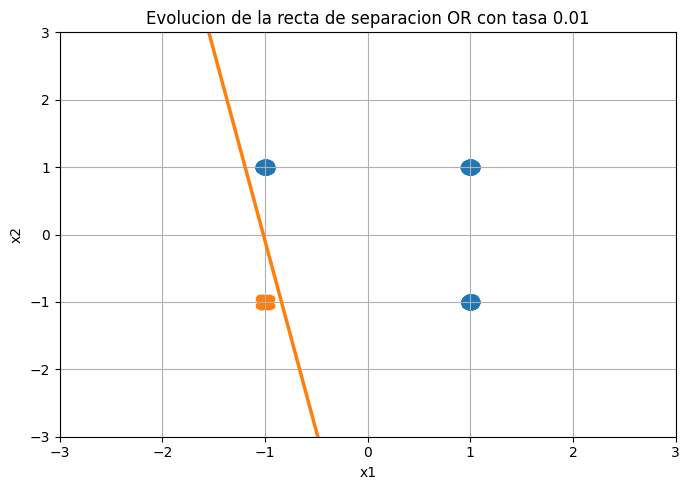

In [40]:
plot(X_train, y_train, p.hist_w, "Evolucion de la recta de separacion OR con tasa 0.01")

Podemos ver que la pendiente de la recta cambia de a poco, ya que el perceptron va ajustando los pesos en pasos muy chicos. 

Época   1 | Errores:   0


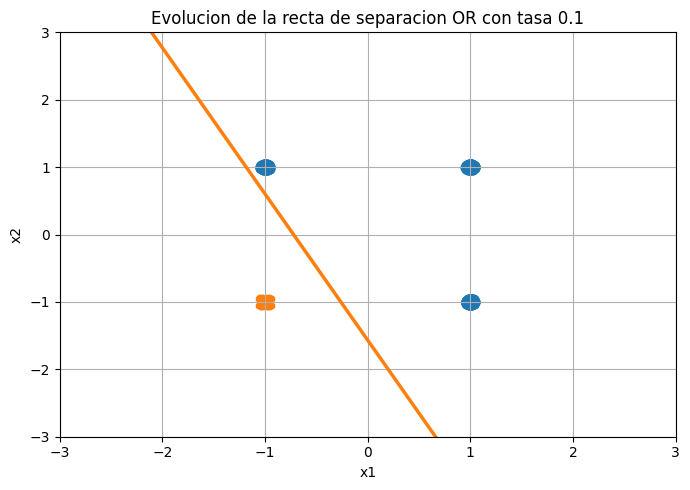

In [41]:
X_train, y_train = PerceptronSimple.cargar_csv("./data/OR_trn.csv")
X_test, y_test = PerceptronSimple.cargar_csv("./data/OR_tst.csv")

p = PerceptronSimple(tasa_aprendizaje=0.1, max_epocas=10, tolerancia=0)
p.entrenar(X_train, y_train)
plot(X_train, y_train, p.hist_w, "Evolucion de la recta de separacion OR con tasa 0.1")


Podemos ver ahora con la nueva tasa de aprendizaje 0.1 los cambios son mas bruscos

Época   1 | Errores: 1007
Época   2 | Errores: 1002
Época   3 | Errores: 1007
Época   4 | Errores: 1009
Época   5 | Errores: 1002
Época   6 | Errores: 1009
Época   7 | Errores: 1509
Época   8 | Errores: 1009
Época   9 | Errores: 1509
Época  10 | Errores: 1509
Época  11 | Errores: 1007
Época  12 | Errores: 1007
Época  13 | Errores: 1007
Época  14 | Errores: 1007
Época  15 | Errores: 1007
Época  16 | Errores: 1509
Época  17 | Errores: 1007
Época  18 | Errores: 1007
Época  19 | Errores: 1509
Época  20 | Errores: 1002
Precision en test:  0.57
[array([-0.00397713, -0.03158556,  0.00780659]), array([-0.02397713, -0.00618076,  0.00964819]), array([-0.00397713, -0.02279676,  0.00383999]), array([-0.02397713, -0.00205776, -0.00867261]), array([-0.00397713, -0.01099236,  0.02864119]), array([-0.00397713, -0.00772356, -0.00018321]), array([-0.00397713, -0.00612316,  0.01682059]), array([-0.02397713, -0.02491356,  0.01068899]), array([-0.00397713, -0.00306096,  0.00762439]), array([-0.02397713, -0

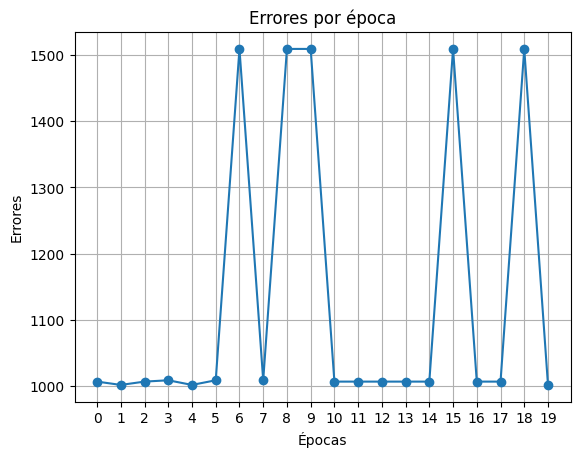

In [44]:
X_xor_train, y_xor_train = PerceptronSimple.cargar_csv("./data/XOR_trn.csv")
X_xor_test, y_xor_test = PerceptronSimple.cargar_csv("./data/XOR_tst.csv")

p1 = PerceptronSimple(tasa_aprendizaje=0.01, max_epocas=20, tolerancia=0)
p1.entrenar(X_xor_train, y_xor_train)

print("Precision en test: ", p1.evaluar(X_xor_test, y_xor_test))
plt.plot(p1.errores, marker="o")
# Eje x solo numeros enteros
plt.xticks(range(len(p1.errores)))

print(p1.hist_w )

plt.title("Errores por época")
plt.xlabel("Épocas")
plt.ylabel("Errores")
plt.grid(True)
plt.show()

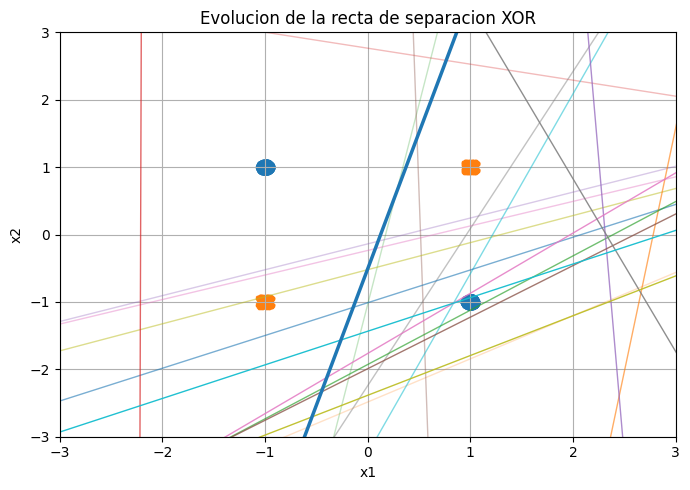

In [45]:

plot(X_xor_train, y_xor_train, p1.hist_w, "Evolucion de la recta de separacion XOR")